## KAGGLE NOTE BOOK

In [1]:
# Imports

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset, Subset

from torchvision import datasets, transforms
import torchvision.transforms as transforms
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print("Device used:",device)


Device used: cuda


# DATA NORMALISATION 

Calcul de la moyenne et de l'écart type pour nos images

In [10]:
import random

dir = "./data/ships_gray/ships_gray"

# Transform pour calculer moyenne/écart-type (pas de normalize)
transform_base = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=dir, transform=transform_base)
loader = DataLoader(dataset, batch_size=64, shuffle=False)

# Calcul moyenne et écart-type sur tout le dataset
somme_totale = 0.0
somme_carres_totale = 0.0
nombre_total_pixels = 0

for images, _ in loader:
    somme_totale += images.sum()
    somme_carres_totale += (images ** 2).sum()
    nombre_total_pixels += images.numel()

moyenne = somme_totale / nombre_total_pixels
variance = (somme_carres_totale / nombre_total_pixels) - (moyenne ** 2)
ecart_type = torch.sqrt(variance)
print(f"Moyenne: {moyenne:.4f} | Écart-type: {ecart_type:.4f}")

# Dataset brut (PIL) pour les splits et AugTransform
dataset_brut = datasets.ImageFolder(root=dir)

# Petit set pour l'overfit (construit depuis dataset_brut)
class_indices = defaultdict(list)
for idx in range(len(dataset_brut)):
    _, label = dataset_brut[idx]
    class_indices[label].append(idx)

selected_indices = []
for label, indices in class_indices.items():
    print(f"Classe {label} → {len(indices)} images")
    selected_indices += random.sample(indices, 10)

small_set_brut = Subset(dataset_brut, selected_indices)

print(f"Total images mini-set: {len(small_set_brut)}")
print(f"Classes: {dataset_brut.classes}")
print(f"Nombre de classes: {len(dataset_brut.classes)}")

Moyenne: 0.5419 | Écart-type: 0.2419
Classe 0 → 3128 images
Classe 1 → 6266 images
Classe 2 → 2676 images
Classe 3 → 6251 images
Classe 4 → 1826 images
Classe 5 → 5981 images
Classe 6 → 3172 images
Classe 7 → 3014 images
Classe 8 → 2562 images
Classe 9 → 3104 images
Total images mini-set: 100
Classes: ['coastguard_scaled', 'containership_scaled', 'corvette_scaled', 'cruiser_scaled', 'cv_scaled', 'destroyer_scaled', 'methanier_scaled', 'smallfish_scaled', 'submarine_scaled', 'tug_scaled']
Nombre de classes: 10


# FINETUNING

In [11]:
# training pourcentage (deafault 80%)
training_repartition = 0.8
validation_repartition = 0.15
overfit_repartition = 0.05

# load workers (thread cpu)
workers = 0 

# bach_size
bach_size = 64

#optimisation
torch.backends.cudnn.benchmark = True

#training
num_epochs = 15

#averfit learning rate
overfit_lr =  5e-4#3e-3, 3e-3
# lr classic
lr = 1e-3

# DATASET INFORMATION

In [12]:
classes = dataset_brut.classes
taille_totale = len(dataset_brut)
taille_train = int(training_repartition * taille_totale)
taille_test = int(validation_repartition * taille_totale)
taille_overfit = taille_totale - taille_train - taille_test

## DATA AUGEMENTATION AND NORMALISATION

In [13]:
# training set
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([moyenne.item()], [ecart_type.item()])
])

# test set
transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([moyenne.item()], [ecart_type.item()])
])

trainset_brut, testset_brut, overfitset_brut = random_split(dataset_brut, [taille_train, taille_test, taille_overfit])

class AugTransform(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.subset[index]
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

trainset  = AugTransform(trainset_brut,   transform=transform_train)
testset   = AugTransform(testset_brut,    transform=transform_test)
overfitset = AugTransform(overfitset_brut, transform=transform_test)
small_set  = AugTransform(small_set_brut,  transform=transform_test)

overfit_loader = DataLoader(overfitset, batch_size=16, shuffle=True)

train_loader = DataLoader(
    trainset,
    batch_size=bach_size,
    shuffle=True,
    num_workers=workers,
    pin_memory=True
)

test_loader = DataLoader(
    testset,
    batch_size=bach_size,
    shuffle=False,
    num_workers=workers,
    pin_memory=True
)

print("Preprocessing ready")
print(f"Train: {len(trainset)} | Test: {len(testset)} | Overfit: {len(overfitset)} | Small: {len(small_set)}")

Preprocessing ready
Train: 30384 | Test: 5697 | Overfit: 1899 | Small: 100


# CNN ARCHITECTURE

In [14]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=len(dataset.classes), dropout=0.3):
        super().__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        return self.classifier(x)

model = CNN()

# Comptage des paramètres
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nNombre de paramètres entraînables : {count_params(model):,}")


Nombre de paramètres entraînables : 305,130


In [15]:
print(dataset.classes)


['coastguard_scaled', 'containership_scaled', 'corvette_scaled', 'cruiser_scaled', 'cv_scaled', 'destroyer_scaled', 'methanier_scaled', 'smallfish_scaled', 'submarine_scaled', 'tug_scaled']


# TRAINING 

In [16]:



model = CNN(dropout=0.0).to(device)

optimizer = torch.optim.Adam(model.parameters(), 1e-3)
criterion = nn.CrossEntropyLoss()

small_loader = DataLoader(small_set, batch_size=len(small_set), shuffle=True)
#overfit set


for epoch in range(50):
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()
    model.train()

    correct = 0
    total = 0

    for images, labels in small_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

    print(f"Epoch {epoch} | Acc: {correct/total:.4f}")





Epoch 0 | Acc: 0.1000
Epoch 1 | Acc: 0.1600
Epoch 2 | Acc: 0.3100
Epoch 3 | Acc: 0.3100
Epoch 4 | Acc: 0.3200
Epoch 5 | Acc: 0.3500
Epoch 6 | Acc: 0.3600
Epoch 7 | Acc: 0.3900
Epoch 8 | Acc: 0.4200
Epoch 9 | Acc: 0.4200
Epoch 10 | Acc: 0.4800
Epoch 11 | Acc: 0.4700
Epoch 12 | Acc: 0.4900
Epoch 13 | Acc: 0.5600
Epoch 14 | Acc: 0.6200
Epoch 15 | Acc: 0.6500
Epoch 16 | Acc: 0.6300
Epoch 17 | Acc: 0.6800
Epoch 18 | Acc: 0.6700
Epoch 19 | Acc: 0.6800
Epoch 20 | Acc: 0.7500
Epoch 21 | Acc: 0.6600
Epoch 22 | Acc: 0.6900
Epoch 23 | Acc: 0.7100
Epoch 24 | Acc: 0.7700
Epoch 25 | Acc: 0.8200
Epoch 26 | Acc: 0.7900
Epoch 27 | Acc: 0.7900
Epoch 28 | Acc: 0.8300
Epoch 29 | Acc: 0.8800
Epoch 30 | Acc: 0.8500
Epoch 31 | Acc: 0.8700
Epoch 32 | Acc: 0.8700
Epoch 33 | Acc: 0.9300
Epoch 34 | Acc: 0.8800
Epoch 35 | Acc: 0.9200
Epoch 36 | Acc: 0.9500
Epoch 37 | Acc: 0.9600
Epoch 38 | Acc: 0.8900
Epoch 39 | Acc: 0.9500
Epoch 40 | Acc: 0.9400
Epoch 41 | Acc: 0.9400
Epoch 42 | Acc: 0.9900
Epoch 43 | Acc: 0.970

In [17]:
model = CNN(dropout=0.3).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)


best_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    scheduler.step()


    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.6907
Epoch 2, Loss: 1.3248
Epoch 3, Loss: 1.1400
Epoch 4, Loss: 1.0331
Epoch 5, Loss: 0.9512
Epoch 6, Loss: 0.8956
Epoch 7, Loss: 0.8359
Epoch 8, Loss: 0.7853
Epoch 9, Loss: 0.7478
Epoch 10, Loss: 0.7195
Epoch 11, Loss: 0.6754
Epoch 12, Loss: 0.6616
Epoch 13, Loss: 0.6296
Epoch 14, Loss: 0.5965
Epoch 15, Loss: 0.5820


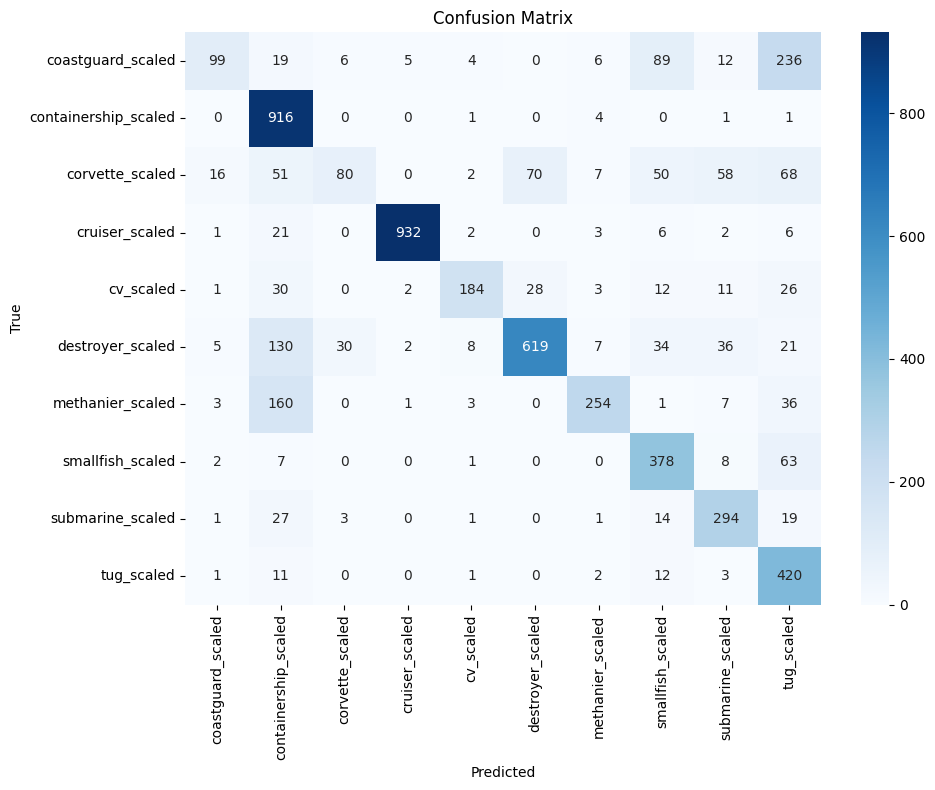

                      precision    recall  f1-score   support

   coastguard_scaled       0.77      0.21      0.33       476
containership_scaled       0.67      0.99      0.80       923
     corvette_scaled       0.67      0.20      0.31       402
      cruiser_scaled       0.99      0.96      0.97       973
           cv_scaled       0.89      0.62      0.73       297
    destroyer_scaled       0.86      0.69      0.77       892
    methanier_scaled       0.89      0.55      0.68       465
    smallfish_scaled       0.63      0.82      0.72       459
    submarine_scaled       0.68      0.82      0.74       360
          tug_scaled       0.47      0.93      0.62       450

            accuracy                           0.73      5697
           macro avg       0.75      0.68      0.67      5697
        weighted avg       0.77      0.73      0.71      5697



In [18]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=classes))

In [ ]:
print(classification_report(all_labels, all_preds, target_names=classes))